In [1]:
import torch
import torch.nn as nn
from torchvision import models
import torchvision.transforms as transforms
from torchvision import datasets, transforms
import os
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, ConcatDataset
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
import pandas as pd
import random
import torchvision.transforms.functional as F
from torchvision.transforms.functional import invert
import cv2
import numpy as np
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [2]:
# Definição de classe de balanceamento de classes por augmentation
class SmartBalancedDataset(Dataset):
    def __init__(self, root_dir, transform=None, mode='train'):
        self.root_dir = root_dir
        self.transform = transform
        self.mode = mode

        # Lista de arquivos
        self.files = [
            f for f in os.listdir(root_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        # Extrair classes
        self.class_tags = []
        for fname in self.files:
            parts = fname.split('_')
            if len(parts) >= 5:
                tag = parts[4]
            else:
                tag = 'UNK'
            self.class_tags.append(tag)

        self.class_names = sorted(list(set(self.class_tags)))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.class_names)}
        
        # Análise detalhada
        self.class_counts = Counter(self.class_tags)
        print("📊 DISTRIBUIÇÃO DAS CLASSES:")
        for cls, count in self.class_counts.items():
            print(f"   {cls}: {count} amostras")
            
        # Estratégias específicas por classe
        self.class_strategies = {
            'ESF': {'augmentation': 'heavy', 'focus': 'high'},  # Já está boa
            'ETR': {'augmentation': 'moderate', 'focus': 'high'},  # Precisamos melhorar
            'LMT': {'augmentation': 'heavy', 'focus': 'medium'},   # Manter
            'RET': {'augmentation': 'light', 'focus': 'medium'}    # Já está boa
        }

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        path = os.path.join(self.root_dir, fname)

        img = Image.open(path).convert("RGB")
        
        parts = fname.split('_')
        tag = parts[4] if len(parts) >= 5 else 'UNK'
        label = self.class_to_idx[tag]
        
        # Aplicar augmentação específica por classe
        if self.mode == 'train':
            img = self._apply_class_specific_augmentation(img, tag)
        
        if self.transform:
            img = self.transform(img)

        return img, label

    def _apply_class_specific_augmentation(self, img, tag):
        """Augmentação específica para cada classe"""
        strategy = self.class_strategies.get(tag, {'augmentation': 'moderate'})
        
        img_np = np.array(img)
        
        if strategy['augmentation'] == 'heavy':
            # Augmentação pesada para classes problemáticas
            # Variação de cor
            alpha = np.random.uniform(0.7, 1.3)
            beta = np.random.randint(-40, 40)
            img_np = cv2.convertScaleAbs(img_np, alpha=alpha, beta=beta)
            
            # Rotação
            angle = np.random.uniform(-25, 25)
            h, w = img_np.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            img_np = cv2.warpAffine(img_np, M, (w, h))
            
        elif strategy['augmentation'] == 'moderate':
            # Augmentação moderada
            alpha = np.random.uniform(0.8, 1.2)
            beta = np.random.randint(-20, 20)
            img_np = cv2.convertScaleAbs(img_np, alpha=alpha, beta=beta)
            
        # Sempre aplicar flip horizontal aleatório
        if np.random.random() > 0.5:
            img_np = cv2.flip(img_np, 1)
            
        return Image.fromarray(img_np)


In [3]:
# ========== TRANSFORMAÇÕES OTIMIZADAS ==========
train_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ========== CARREGAR DADOS ==========
print("\n=== CARREGANDO DADOS COM ESTRATÉGIAS ESPECÍFICAS ===")
dataset = SmartBalancedDataset("/home/hackathon/Lamina/train", transform=None, mode='train')



=== CARREGANDO DADOS COM ESTRATÉGIAS ESPECÍFICAS ===
📊 DISTRIBUIÇÃO DAS CLASSES:
   ESF: 100 amostras
   RET: 600 amostras
   ETR: 350 amostras
   LMT: 50 amostras


In [4]:
# Usando o split estratificado, mas verificar se da pra usar
# split comum

# Split estratificado
train_indices, test_indices = train_test_split(
    range(len(dataset)), 
    test_size=0.2, 
    random_state=42,
    stratify=dataset.class_tags
)

dataset_train = torch.utils.data.Subset(dataset, train_indices)
dataset_test = torch.utils.data.Subset(dataset, test_indices)

# Aplicar transforms
for i in range(len(dataset_train)):
    dataset_train.dataset.transform = train_transform
for i in range(len(dataset_test)):
    dataset_test.dataset.transform = test_transform

In [5]:
loader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=32, shuffle=True)

In [6]:
# Contagem das classes
# extrai as classes (nomes, não índices)
classes = [dataset.class_tags[i] for i in range(len(dataset))]

# conta quantas vezes cada classe aparece
contagem = Counter(classes)

# exibe
print("Contagem de classes:")
for classe, qtd in contagem.items():
    print(f"{classe}: {qtd}")

Contagem de classes:
ESF: 100
RET: 600
ETR: 350
LMT: 50


In [7]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import models
from tqdm import tqdm

# --- Classe do ensemble (ajustada para device) ---
class SimpleEnsemble:
    def __init__(self, device="cpu"):
        self.device = torch.device(device)
        # InceptionV3 (remoção da cabeça)
        self.model1 = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        self.model1.aux_logits = False
        self.model1.fc = nn.Identity()
        # ResNet50 (remoção da cabeça)
        self.model2 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.model2.fc = nn.Identity()

        # Move os modelos para device e coloca em eval
        for model in [self.model1, self.model2]:
            model.to(self.device).eval()
            # desativa gradientes para economizar memória
            for p in model.parameters():
                p.requires_grad = False

    @torch.no_grad()
    def extract_features(self, x):
        """
        x: tensor [B, C, H, W] já no mesmo device que os modelos.
        retorna: tensor [B, D] com features concatenadas (feat_inception || feat_resnet)
        """
        # Certifica-se de que o batch está no device
        if x.device != self.device:
            x = x.to(self.device)
        # Algumas arquiteturas (Inception) esperam tamanho 299 — cuidado com transforms.
        feat1 = self.model1(x)   # saída Inception -> [B, D1]
        feat2 = self.model2(x)   # saída ResNet50 -> [B, D2]
        return torch.cat([feat1, feat2], dim=1)

# --- Função de extração que usa DataLoader e traz features para CPU ---
def extract_features_smart(dataset, feature_extractor, batch_size=4, num_workers=4):
    """
    dataset: torch.utils.data.Dataset
    feature_extractor: instância de SimpleEnsemble (com device já configurado)
    retorna: (features, labels) ambos tensors em CPU
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    features_list = []
    labels_list = []

    # iterar sem cálculo de gradientes (já feito internamente, mas repetimos por segurança)
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Extraindo features"):
            # imgs devem ser enviados para device dentro do extractor
            feats = feature_extractor.extract_features(imgs)  # feats está no device do modelo
            features_list.append(feats.cpu())  # traz pra CPU pra liberar VRAM
            labels_list.append(lbls.cpu())

    features = torch.cat(features_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    return features, labels

# --- Exemplo de uso ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando device:", device)

# cria o extrator (models movidos para device dentro do construtor)
feature_extractor = SimpleEnsemble(device=device)

# supondo que dataset_train / dataset_test já estejam definidos
features_train, labels_train = extract_features_smart(dataset_train, feature_extractor, batch_size=8)
features_test,  labels_test  = extract_features_smart(dataset_test,  feature_extractor, batch_size=8)

print("features_train shape:", features_train.shape)  # ex: [N_train, D1 + D2]
print("features_test  shape:", features_test.shape)

Usando device: cuda


Extraindo features: 100%|██████████| 28/28 [00:01<00:00, 18.34it/s]

features_train shape: torch.Size([880, 4096])
features_test  shape: torch.Size([220, 4096])


In [8]:
X_train = features_train.numpy()
y_train = labels_train.numpy()
X_test = features_test.numpy()
y_test = labels_test.numpy()

pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

try:
    lda = LDA(n_components=min(3, len(dataset.class_names)-1))
    Z_train = lda.fit_transform(X_train_pca, y_train)
    Z_test = lda.transform(X_test_pca)
except:
    Z_train = X_train_pca[:, :10]
    Z_test = X_test_pca[:, :10]

Z_train = torch.from_numpy(Z_train).float()
Z_test = torch.from_numpy(Z_test).float()
y_train = torch.from_numpy(y_train).long()
y_test = torch.from_numpy(y_test).long()

print(f"✅ Shape das features reduzidas (treino): {Z_train.shape}")
#print(f"✅ Variância explicada (aproximada): {S_train.pow(2).sum().item():.2e}")

✅ Shape das features reduzidas (treino): torch.Size([880, 3])


In [9]:
# y_train é só um alias mais intuitivo para labels_train
# definir y_train acho que não é necessario pois já definiu logo acima
#y_train = labels_train

# Cria o Dataset e DataLoader de treino
class FeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.float()
        self.y = y.long()  # classes inteiras
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = FeatureDataset(Z_train, y_train)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_ds  = FeatureDataset(Z_test,  y_test)
test_dl  = DataLoader(test_ds,  batch_size=32, shuffle=False)

print(f"✅ Dataset de treino criado com {len(train_ds)} amostras.")

✅ Dataset de treino criado com 880 amostras.


In [10]:
# número de classes com base nos labels do treino
num_classes = len(torch.unique(y_train))

class Classifier(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# o input_dim agora vem de Z_train (não de Z)
model = Classifier(Z_train.shape[1], num_classes).to(device)
'''

import torch
from torch import nn

num_classes = len(torch.unique(y_train))

class Classifier(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Classifier(Z_train.shape[1], num_classes).to(device)
'''
print(f"✅ Modelo inicializado no device: {device}")
print(f"✅ Input dim: {Z_train.shape[1]} | Num classes: {num_classes}")

✅ Modelo inicializado no device: cuda
✅ Input dim: 3 | Num classes: 4


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(25):
    model.train()
    total_loss = 0

    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    avg_loss = total_loss / len(train_ds)

    # --- avaliação simples ---
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)

    acc = correct / total
    print(f"[{epoch+1:02d}] loss={avg_loss:.5f} | acc={acc*100:.2f}%")

[01] loss=0.82668 | acc=85.91%
[02] loss=0.44451 | acc=88.18%
[03] loss=0.36335 | acc=87.27%
[04] loss=0.30292 | acc=88.18%
[05] loss=0.28732 | acc=88.18%
[06] loss=0.28148 | acc=88.64%
[07] loss=0.26606 | acc=87.27%
[08] loss=0.28784 | acc=87.73%
[09] loss=0.27307 | acc=87.27%
[10] loss=0.27733 | acc=86.82%
[11] loss=0.26429 | acc=88.64%
[12] loss=0.24959 | acc=87.73%
[13] loss=0.27787 | acc=88.18%
[14] loss=0.26831 | acc=87.27%
[15] loss=0.25505 | acc=89.09%
[16] loss=0.25155 | acc=88.18%
[17] loss=0.25691 | acc=87.73%
[18] loss=0.26365 | acc=88.64%
[19] loss=0.24619 | acc=89.09%
[20] loss=0.24473 | acc=88.18%
[21] loss=0.25413 | acc=88.64%
[22] loss=0.25175 | acc=88.64%
[23] loss=0.24427 | acc=88.64%
[24] loss=0.24933 | acc=88.64%
[25] loss=0.24923 | acc=88.18%


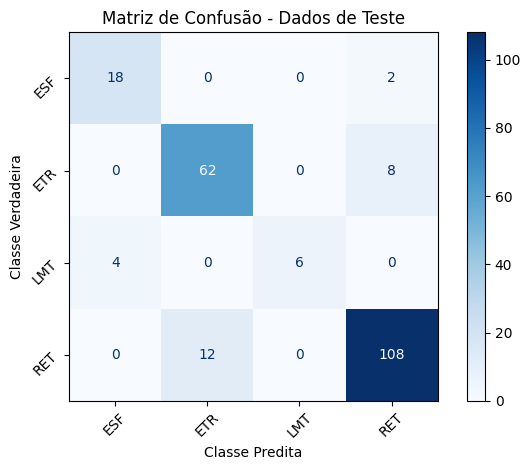

✅ Acurácia total: 88.18%
📊 F1-score (macro):     84.40%
📊 F1-score (weighted):  88.10%
📈 F1-score por classe:
   ESF: 85.71%
   ETR: 86.11%
   LMT: 75.00%
   RET: 90.76%


In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    preds = []
    reals = []
    for xb, yb in test_dl:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb).argmax(1).cpu()
        preds.append(pred)
        reals.append(yb.cpu())

preds = torch.cat(preds)
reals = torch.cat(reals)

# --- Matriz de confusão ---
cm = confusion_matrix(reals, preds)

# se quiser os nomes das classes reais:
if hasattr(dataset_train, "class_tags"):
    # caso esteja usando ImageTitleDataset com .class_tags
    display_labels = sorted(set(dataset_train.class_tags))
elif "class_to_idx" in dir(dataset_train):
    # caso use DatasetFolder padrão
    idx_to_class = {v: k for k, v in dataset_train.class_to_idx.items()}
    display_labels = [idx_to_class[i] for i in range(len(idx_to_class))]
else:
    # fallback genérico
    display_labels = [*range(num_classes)]

# --- Define os nomes das classes manualmente ---
class_names = ['ESF', 'ETR', 'LMT', 'RET']

# --- Exibe a matriz com legenda correta ---
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")

plt.title("Matriz de Confusão - Dados de Teste")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Verdadeira")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Acurácia geral ---
acc = 100 * (cm.diagonal().sum() / cm.sum())
print(f"✅ Acurácia total: {acc:.2f}%")

# --- F1-score geral e por classe ---
f1_macro = f1_score(reals, preds, average="macro") * 100
f1_weighted = f1_score(reals, preds, average="weighted") * 100
f1_per_class = f1_score(reals, preds, average=None) * 100  # um valor por classe

print(f"📊 F1-score (macro):     {f1_macro:.2f}%")
print(f"📊 F1-score (weighted):  {f1_weighted:.2f}%")
print("📈 F1-score por classe:")
for name, score in zip(class_names, f1_per_class):
    print(f"   {name}: {score:.2f}%")

In [ ]:
# ===============================================
# ======== PREDIÇÃO SOBRE O CONJUNTO DE TESTE ========
# ===============================================

import os
import torch
import pandas as pd
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# --- Dataset sem rótulos ---
class UnlabeledImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.files = [
            f for f in os.listdir(root_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"))
        ]
        if len(self.files) == 0:
            raise ValueError(f"Nenhuma imagem encontrada em {root_dir}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        path = os.path.join(self.root_dir, fname)
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, fname


# --- 1️⃣ Dataset e DataLoader de teste ---
dataset_teste = UnlabeledImageDataset(
    "/home/hackathon/Lamina/test",
    transform=test_transform  # mesmo transform usado no treino/validação
)
loader_teste = DataLoader(dataset_teste, batch_size=8, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2️⃣ Extrair features com o MESMO ensemble usado no treino ---
print("\n=== EXTRAINDO FEATURES (TESTE) ===")

feature_extractor = SimpleEnsemble(device=device)
feature_extractor.model1.eval()
feature_extractor.model2.eval()

features_teste = []
nomes_arquivos = []

with torch.no_grad():
    for imgs, fnames in tqdm(loader_teste, desc="Extraindo features (teste)"):
        feats = feature_extractor.extract_features(imgs)
        features_teste.append(feats.cpu())
        nomes_arquivos.extend(fnames)

features_teste = torch.cat(features_teste, dim=0)
print(f"✅ Features extraídas: {features_teste.shape}")


# --- 3️⃣ Aplicar o mesmo PCA + LDA já usados no treino ---
print("\n=== APLICANDO PCA + LDA ===")

X_test = features_teste.numpy()
X_test_pca = pca.transform(X_test)

try:
    Z_teste = lda.transform(X_test_pca)
    print(f"✅ PCA + LDA aplicados: {Z_teste.shape}")
except Exception as e:
    print("⚠️ Erro no LDA, usando apenas PCA:", e)
    Z_teste = X_test_pca[:, :Z_train.shape[1]]

Z_teste = torch.from_numpy(Z_teste).float().to(device)


# --- 4️⃣ Fazer predições com o modelo já treinado ---
print("\n=== GERANDO PREDIÇÕES ===")

model.eval()
preds = []
probs = []

with torch.no_grad():
    for i in range(0, len(Z_teste), 32):
        xb = Z_teste[i:i+32]
        out = model(xb)
        prob = torch.softmax(out, dim=1)
        pred = prob.argmax(1).cpu()
        preds.append(pred)
        probs.append(prob.max(1).values.cpu())

preds = torch.cat(preds)
probs = torch.cat(probs)
print(f"✅ Predições geradas: {len(preds)} imagens")


# --- 5️⃣ Mapeia índices para classes ---
if hasattr(dataset_train, "dataset"):
    base_dataset = dataset_train.dataset
else:
    base_dataset = dataset_train

idx_to_class = {v: k for k, v in base_dataset.class_to_idx.items()}
nomes_classes = [idx_to_class[p.item()] for p in preds]


# --- 6️⃣ Monta DataFrame e salva CSV ---
df_result = pd.DataFrame({
    "img": nomes_arquivos,
    "classe": nomes_classes
})[["img", "classe"]]

out_path = "/home/hackathon/Gustavo/Resultado dos testes/predicoes_teste.csv"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df_result.to_csv(out_path, index=False)

print(f"✅ Resultados salvos em: {out_path}")
print(df_result.head())


=== EXTRAINDO FEATURES (TESTE) ===


Extraindo features (teste):  12%|█▎        | 7/56 [00:18<02:12,  2.70s/it]

In [ ]:
# ===============================================
# ======== PREDIÇÃO SOBRE O CONJUNTO DE TESTE ========
# ===============================================

import os
import torch
import pandas as pd
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# --- Dataset sem rótulos ---
class UnlabeledImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.files = [
            f for f in os.listdir(root_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"))
        ]
        if len(self.files) == 0:
            raise ValueError(f"Nenhuma imagem encontrada em {root_dir}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        path = os.path.join(self.root_dir, fname)
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, fname


# --- 1️⃣ Dataset e DataLoader de teste ---
dataset_teste = UnlabeledImageDataset(
    "/home/hackathon/Lamina/test",
    transform=test_transform  # mesmo transform usado no treino/validação
)
loader_teste = DataLoader(dataset_teste, batch_size=8, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2️⃣ Extrair features com o MESMO ensemble usado no treino ---
print("\n=== EXTRAINDO FEATURES (TESTE) ===")

feature_extractor = SimpleEnsemble(device=device)
feature_extractor.model1.eval()
feature_extractor.model2.eval()

features_teste = []
nomes_arquivos = []

with torch.no_grad():
    for imgs, fnames in tqdm(loader_teste, desc="Extraindo features (teste)"):
        feats = feature_extractor.extract_features(imgs)
        features_teste.append(feats.cpu())
        nomes_arquivos.extend(fnames)

features_teste = torch.cat(features_teste, dim=0)
print(f"✅ Features extraídas: {features_teste.shape}")


# --- 3️⃣ Aplicar o mesmo PCA + LDA já usados no treino ---
print("\n=== APLICANDO PCA + LDA ===")

X_test = features_teste.numpy()
X_test_pca = pca.transform(X_test)

try:
    Z_teste = lda.transform(X_test_pca)
    print(f"✅ PCA + LDA aplicados: {Z_teste.shape}")
except Exception as e:
    print("⚠️ Erro no LDA, usando apenas PCA:", e)
    Z_teste = X_test_pca[:, :Z_train.shape[1]]

Z_teste = torch.from_numpy(Z_teste).float().to(device)


# --- 4️⃣ Fazer predições com o modelo já treinado ---
print("\n=== GERANDO PREDIÇÕES ===")

model.eval()
preds = []
probs = []

with torch.no_grad():
    for i in range(0, len(Z_teste), 32):
        xb = Z_teste[i:i+32]
        out = model(xb)
        prob = torch.softmax(out, dim=1)
        pred = prob.argmax(1).cpu()
        preds.append(pred)
        probs.append(prob.max(1).values.cpu())

preds = torch.cat(preds)
probs = torch.cat(probs)
print(f"✅ Predições geradas: {len(preds)} imagens")


# --- 5️⃣ Mapeia índices para classes ---
if hasattr(dataset_train, "dataset"):
    base_dataset = dataset_train.dataset
else:
    base_dataset = dataset_train

idx_to_class = {v: k for k, v in base_dataset.class_to_idx.items()}
nomes_classes = [idx_to_class[p.item()] for p in preds]


# --- 6️⃣ Monta DataFrame e salva CSV ---
df_result = pd.DataFrame({
    "img": nomes_arquivos,
    "classe": nomes_classes
})[["img", "classe"]]

out_path = "/home/hackathon/Gustavo/Resultado dos testes/predicoes_teste.csv"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df_result.to_csv(out_path, index=False)

print(f"✅ Resultados salvos em: {out_path}")
print(df_result.head())


=== EXTRAINDO FEATURES (TESTE) ===


Extraindo features (teste):  12%|█▎        | 7/56 [00:18<02:12,  2.70s/it]